# Laboratorio 4: Simulación de eventos discretos
## 5.1 Sistema de línea de espera con un servidor (G/G/1)

**Curso:** Simulación Computacional · Universidad de los Llanos · **Estudiante:** Duván Felipe Baquero · **Código:** 160005002

Este cuaderno parte de la copia del ejemplo del profesor *Sistema de línea de espera con un servidor - G/G/1.ipynb*,
que implementa el modelo de la sección 5.5.1 de [Rios08]. Se conservan sus rutinas `Llegada` y `Servidor`,
los dos generadores congruenciales y el bucle principal con la lista de sucesos `TSuc = {tLL, tS}`. Los cambios
hechos sobre el ejemplo son estos:

1. `GenerarX` y `GenerarY` leen los parámetros del escenario activo en lugar de tener `vlambda = 5` fijo.
2. Para el escenario B se agregó un generador normal por el **método polar** (con `gencongru2` como fuente de
   uniformes) y el truncamiento en cero que pide la nota de la guía.
3. El bucle principal quedó dentro de la función `simular()` para poder repetirlo 10 veces.
4. **Corrección del cálculo de los tiempos medios.** Las listas `LL`, `S` y `Serv` empiezan con un valor
   ficticio `0.0` en la posición 0, así que el cliente $i$ está en la posición $i$. El ejemplo sumaba las
   posiciones `0 ... NLL-1`, con lo que metía el cero ficticio y dejaba por fuera al último cliente. Aquí se
   suman las posiciones `1 ... NLL`.

En el ejemplo el parámetro $\lambda$ de la exponencial es una **tasa**: $X = -\ln(1-U)/\lambda$, con media $1/\lambda$.
Se mantiene esa convención.

In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

def guardar(nombre):
    # guarda la figura para el informe solo si existe la carpeta 'figuras'
    if os.path.isdir("figuras"):
        plt.savefig(f"figuras/{nombre}.pdf", bbox_inches="tight")

### Generadores de números pseudoaleatorios y de variables aleatorias

Son los mismos dos generadores congruenciales del ejemplo, con las mismas semillas. `reiniciar_semillas()`
los devuelve al estado inicial al comienzo de cada escenario, de modo que la corrida 1 de cada escenario es
reproducible y las corridas 2 a 10 continúan la secuencia (por eso son distintas entre sí).

In [2]:
M = 99999.0      # "infinito": suceso no programado

def reiniciar_semillas():
    global Xant1, Xant2, normal_guardada
    Xant1 = 434287492
    Xant2 = 5187324426
    normal_guardada = None

def gencongru1():
    global Xant1
    a = 134775813
    c = 1
    m = 2**32
    Xnext = (a * Xant1 + c) % m
    Xant1 = Xnext
    U = Xnext / m
    return U

def gencongru2():
    global Xant2
    a = 1140671485
    c = 12820163
    m = 2**24
    Xnext = (a * Xant2 + c) % m
    Xant2 = Xnext
    U = Xnext / m
    return U

def normal_polar():
    # método polar: produce dos N(0,1) por cada par aceptado; la segunda se guarda para la siguiente llamada
    global normal_guardada
    if normal_guardada is not None:
        z, normal_guardada = normal_guardada, None
        return z
    while True:
        v1 = 2 * gencongru2() - 1
        v2 = 2 * gencongru2() - 1
        s = v1 * v1 + v2 * v2
        if 0 < s <= 1:
            k = math.sqrt(-2 * math.log(s) / s)
            normal_guardada = v2 * k
            return v1 * k

ESC = {}   # parámetros del escenario activo

def GenerarX():
    # tiempo entre llegadas ~ Exp(lambda), lambda como tasa
    U = gencongru1()
    X = -(math.log(1 - U)) / float(ESC["lam_llegadas"])
    return X

def GenerarY():
    # tiempo de servicio
    if ESC["servicio"] == "exp":
        U = gencongru2()
        Y = -(math.log(1 - U)) / float(ESC["lam_servicio"])
    else:
        Y = ESC["mu"] + ESC["sigma"] * normal_polar()
        if Y < 0:          # nota de la guía: los valores negativos se truncan a cero
            Y = 0.0
    return Y

### Rutinas de sucesos (tomadas del ejemplo)

`Llegada` atiende la llegada de un cliente: actualiza el reloj y el número de clientes $n$, programa la
siguiente llegada si ocurre antes de $T$ y, si el servidor estaba libre ($n = 1$), programa la salida.
`Servidor` atiende la salida de un cliente: baja $n$ y, si queda gente, programa la siguiente salida.

In [3]:
def Llegada(tsuc):
    global n, NLL, NS, t, S, Serv, LL, at, an
    t = tsuc
    n = n + 1
    LLt.append(t)
    at.append(t)
    an.append(n)

    NLL = NLL + 1
    LL.append(t)

    X = GenerarX()

    if (t + X) < T:
        TSuc['tLL'] = t + X
    if n == 1:
        Y = GenerarY()
        TSuc['tS'] = t + Y
        Serv.append(Y)

def Servidor(tsuc):
    global n, NLL, NS, t, S, Serv, LL, at, an
    t = tsuc
    n = n - 1

    St.append(t)
    at.append(t)
    an.append(n)

    NS = NS + 1
    S.append(t)

    if n > 0:
        Y = GenerarY()
        TSuc['tS'] = t + Y
        Serv.append(Y)

### Programa principal

Es el mismo bucle del ejemplo. Mientras haya algún suceso programado se ejecuta el más próximo. Al terminar
se calculan las cinco medidas de desempeño. La única diferencia en el bucle es que, en caso de empate exacto
entre llegada y salida, se atiende primero la llegada (`<=`); con `<` en las dos comparaciones un empate
dejaría el bucle girando sin avanzar.

In [4]:
def simular():
    global t, tsuc, NLL, NS, n, at, an, LLt, St, TSuc, LL, S, Serv
    at, an, LLt, St = [], [], [], []
    t = tsuc = NLL = NS = n = 0

    at.append(t)
    an.append(n)

    TSuc = {"tLL": M, "tS": M}

    LL = [0.0]      # posición 0: valor ficticio, igual que en el ejemplo
    S = [0.0]
    Serv = [0.0]

    X = GenerarX()

    if X > T:
        Tp = t_med_sistema = t_med_cola = 0.0
    else:
        Llegada(X)
        while (TSuc['tLL'] != M) | (TSuc['tS'] != M):
            if TSuc['tLL'] <= TSuc['tS']:
                tsuc = TSuc['tLL']
                TSuc['tLL'] = M
                Llegada(tsuc)
            elif TSuc['tS'] < TSuc['tLL']:
                tsuc = TSuc['tS']
                TSuc['tS'] = M
                Servidor(tsuc)

        Tp = max(0, t - T)
        acumulo1 = acumulo2 = 0.0
        for ind in range(1, NLL + 1):          # clientes 1..NLL (corrección)
            acumulo1 = acumulo1 + S[ind] - LL[ind]
            acumulo2 = acumulo2 + S[ind] - LL[ind] - Serv[ind]
        t_med_sistema = acumulo1 / NLL
        t_med_cola = acumulo2 / NLL

    return {"Tiempo medio en el sistema": t_med_sistema,
            "Tiempo medio en la cola": t_med_cola,
            "Tiempo desde T hasta la salida del último": Tp,
            "Máximo de clientes en el sistema": int(max(an)),
            "Total de clientes": NLL}

def valor_con_indices_del_ejemplo():
    # lo que habría dado el cálculo original (posiciones 0..NLL-1), solo para comparar
    return sum(S[i] - LL[i] for i in range(NLL)) / NLL

def graficar(titulo, nombre):
    fig, axs = plt.subplots(3, 1, figsize=(10, 6.2), sharex=True,
                            gridspec_kw={"height_ratios": [1, 1, 3]})
    axs[0].plot(LLt, np.ones(len(LLt)), "r.", ms=4)
    axs[0].set_yticks([]); axs[0].set_ylabel("Llegadas")
    axs[1].plot(St, np.ones(len(St)), "b.", ms=4)
    axs[1].set_yticks([]); axs[1].set_ylabel("Salidas")
    axs[2].step(at, an, where="post", color="#1f4e79", lw=1.2)
    axs[2].axvline(T, color="gray", ls="--", lw=1)
    axs[2].text(T, max(an) * 0.95, "  T", color="gray")
    axs[2].set_xlabel("tiempo (t)"); axs[2].set_ylabel("clientes en el sistema (n)")
    axs[0].set_title(titulo)
    for ax in axs:
        ax.set_xlim(0, max(at))
    plt.tight_layout(); guardar(nombre); plt.show()

def correr_escenario(config, repeticiones=10):
    global ESC
    ESC = config
    reiniciar_semillas()
    filas, traza = [], None
    for k in range(repeticiones):
        res = simular()
        filas.append(res)
        if k == 0:
            traza = {"original": valor_con_indices_del_ejemplo()}
    df = pd.DataFrame(filas, index=pd.RangeIndex(1, repeticiones + 1, name="Corrida"))
    return df, traza

---
### Escenario A

$T = 40$, tiempos entre llegadas $\sim \text{Exp}(\lambda = 5)$ y tiempos de servicio $\sim \text{Exp}(\lambda = 3)$.

Llegan en promedio 5 clientes por unidad de tiempo y el servidor atiende 3, así que la intensidad de tráfico es
$\rho = 5/3 \approx 1{,}67$. Con $\rho > 1$ el sistema no es estable: la cola crece durante toda la ventana
$[0, T]$ y solo se vacía cuando se cierran las llegadas.

**Primera corrida** (con la que se responden las preguntas):

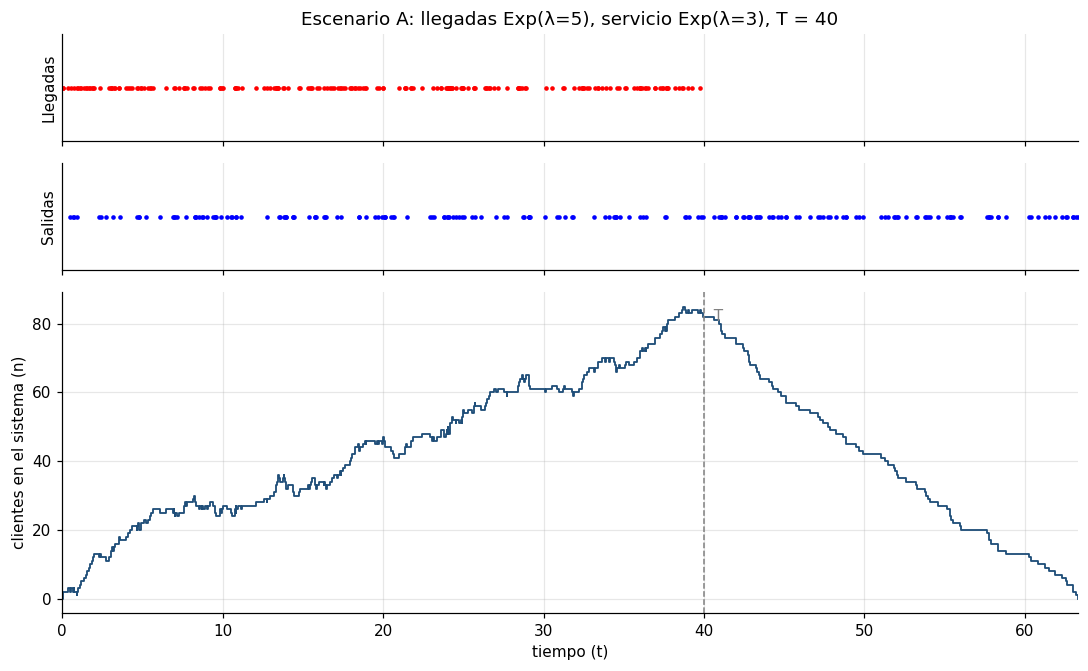

Tiempo medio en el sistema                   : 13.2105
Tiempo medio en la cola                      : 12.8973
Tiempo desde T hasta la salida del último    : 23.3130
Máximo de clientes en el sistema             : 85
Total de clientes                            : 202

(Con los índices del ejemplo original el tiempo medio en el sistema habría dado 13.0940)


In [5]:
T = 40.0
esc_A = {"lam_llegadas": 5, "servicio": "exp", "lam_servicio": 3}

ESC = esc_A
reiniciar_semillas()
res_A1 = simular()
graficar("Escenario A: llegadas Exp(λ=5), servicio Exp(λ=3), T = 40", "51_escA")
for k, v in res_A1.items():
    print(f"{k:45s}: {v:.4f}" if isinstance(v, float) else f"{k:45s}: {v}")
print(f"\n(Con los índices del ejemplo original el tiempo medio en el sistema habría dado {valor_con_indices_del_ejemplo():.4f})")


**Respuestas del escenario A (primera corrida):**

| Pregunta | Resultado |
|---|---|
| ¿Cuál es el tiempo medio de los clientes en el sistema? | 13,2105 |
| ¿Cuál es el tiempo medio de los clientes en la cola? | 12,8973 |
| ¿Cuál es el tiempo transcurrido desde T hasta que el último cliente abandona el sistema? | 23,3130 |
| ¿Cuál es el número máximo de clientes en el sistema? | 85 |
| ¿Cuál es el total de clientes que pasaron por el sistema? | 202 |

La gráfica muestra lo esperado con $\rho = 5/3$: el número de clientes sube casi en línea recta hasta
$T = 40$, llega a 85 y a partir de ahí solo baja, porque ya no entra nadie. La diferencia entre el tiempo en
el sistema y el tiempo en cola es 0,31, muy cerca del tiempo medio de servicio $1/3$. Casi todo el tiempo que
un cliente pasa en el sistema lo pasa esperando.

Sobre la corrección de índices: con el cálculo original el tiempo medio en el sistema habría dado 13,0940,
0,12 menos. La diferencia es pequeña aquí porque hay 202 clientes, pero con pocos clientes pesa más.


**Diez corridas del escenario A:**

In [6]:
df_A, _ = correr_escenario(esc_A, 10)
df_A

,Tiempo medio en el sistema,Tiempo medio en la cola,Tiempo desde T hasta la salida del último,Máximo de clientes en el sistema,Total de clientes
Corrida,,,,,
1,13.2105,12.8973,23.3130,85,202
2,12.0779,11.7775,22.5801,77,208
3,13.0522,12.7117,22.6776,76,183
4,6.1492,5.8583,10.3846,42,163
5,13.9198,13.5397,27.9925,69,177
6,14.0110,13.6833,23.2034,80,190
7,19.4143,19.0511,41.4152,109,224
8,11.7507,11.4337,25.2216,74,204
9,14.8242,14.4811,25.8949,82,191


---
### Escenario B

$T = 40$, tiempos entre llegadas $\sim \text{Exp}(\lambda = 1)$ y tiempos de servicio $\sim N(\mu = 2, \sigma = 1)$
truncada en cero.

Ahora llega en promedio un cliente por unidad de tiempo y cada servicio dura en promedio 2, de modo que
$\rho \approx 2$. Otra vez $\rho > 1$, pero con muchos menos clientes que en A. El truncamiento casi no
cambia la media: $P\{Y < 0\} = \Phi(-2) \approx 2{,}3\,\%$.

**Primera corrida:**

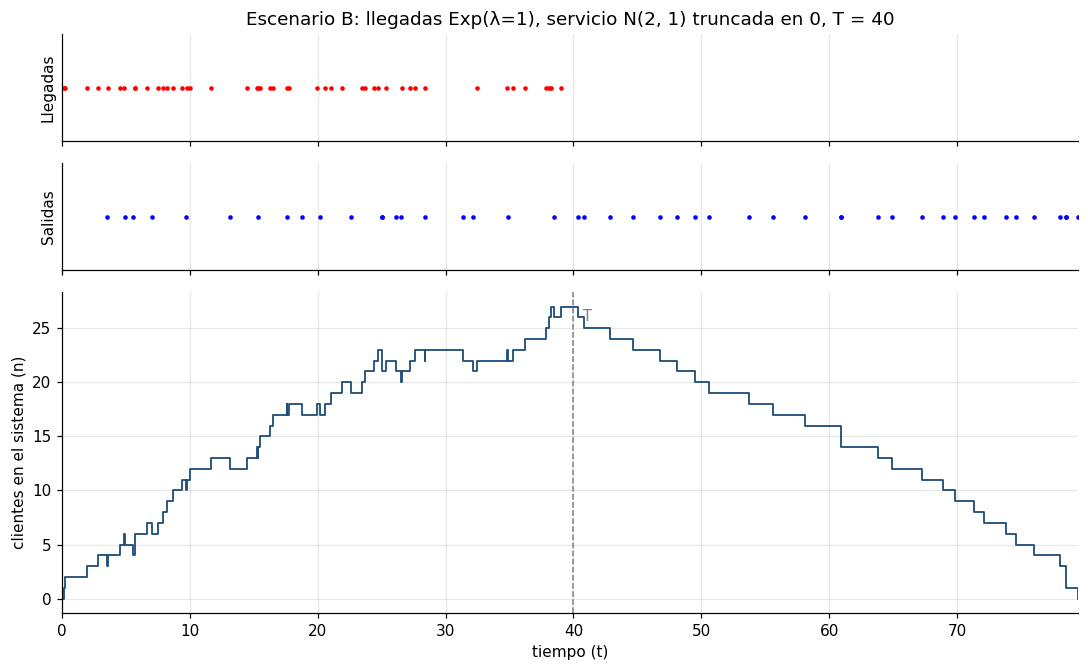

Tiempo medio en el sistema                   : 26.1985
Tiempo medio en la cola                      : 24.5107
Tiempo desde T hasta la salida del último    : 39.4699
Máximo de clientes en el sistema             : 27
Total de clientes                            : 47

Tiempos de servicio generados: media = 1.6878, truncados a cero = 3 de 47


In [7]:
esc_B = {"lam_llegadas": 1, "servicio": "normal", "mu": 2.0, "sigma": 1.0}

ESC = esc_B
reiniciar_semillas()
res_B1 = simular()
graficar("Escenario B: llegadas Exp(λ=1), servicio N(2, 1) truncada en 0, T = 40", "51_escB")
for k, v in res_B1.items():
    print(f"{k:45s}: {v:.4f}" if isinstance(v, float) else f"{k:45s}: {v}")
print(f"\nTiempos de servicio generados: media = {np.mean(Serv[1:]):.4f}, "
      f"truncados a cero = {sum(1 for y in Serv[1:] if y == 0)} de {len(Serv) - 1}")


**Respuestas del escenario B (primera corrida):**

| Pregunta | Resultado |
|---|---|
| ¿Cuál es el tiempo medio de los clientes en el sistema? | 26,1985 |
| ¿Cuál es el tiempo medio de los clientes en la cola? | 24,5107 |
| ¿Cuál es el tiempo transcurrido desde T hasta que el último cliente abandona el sistema? | 39,4699 |
| ¿Cuál es el número máximo de clientes en el sistema? | 27 |
| ¿Cuál es el total de clientes que pasaron por el sistema? | 47 |

Entraron 47 clientes, bastante más que los 40 que se esperan con $\lambda T = 1 \cdot 40$, y la media de sus
tiempos de servicio salió 1,69 en vez de 2 (3 de los 47 quedaron truncados en cero). Para descartar un
problema del generador se probaron aparte 20 000 normales del método polar: media 0,013, desviación 1,002
y Kolmogorov-Smirnov con $p = 0{,}17$. Con 47 datos, una media de 1,69 está a unos dos errores estándar
de 2, así que es variación de la muestra.


**Diez corridas del escenario B:**

In [8]:
df_B, _ = correr_escenario(esc_B, 10)
df_B

,Tiempo medio en el sistema,Tiempo medio en la cola,Tiempo desde T hasta la salida del último,Máximo de clientes en el sistema,Total de clientes
Corrida,,,,,
1,26.1985,24.5107,39.4699,27,47
2,19.2413,17.3586,31.4515,20,37
3,23.1418,21.2682,43.3908,24,44
4,18.5432,16.5342,29.8294,16,34
5,22.2966,20.3283,43.1280,21,42
6,18.7623,16.7262,33.4140,18,36
7,21.6338,19.7010,41.3751,23,42
8,47.9425,45.5503,90.2462,38,54
9,11.0512,8.9061,13.3161,10,24


---
### Tabla 1. Medidas de desempeño para los escenarios A y B luego de 10 simulaciones

Promedio $\pm$ desviación estándar muestral (con $n - 1$ en el denominador).

In [9]:
def pm(df):
    return [f"{m:.4f} ± {s:.4f}" for m, s in zip(df.mean(), df.std(ddof=1))]

tabla1 = pd.DataFrame({"Escenario A": pm(df_A), "Escenario B": pm(df_B)},
                      index=["Tiempo medio de los clientes en el sistema",
                             "Tiempo medio de los clientes en la cola",
                             "Tiempo transcurrido desde T hasta que el último cliente abandona el sistema",
                             "Número máximo de clientes en el sistema",
                             "Total de clientes que pasaron por el sistema"])
tabla1.index.name = "Medida de desempeño"
tabla1

,Escenario A,Escenario B
Medida de desempeño,,
Tiempo medio de los clientes en el sistema,12.9742 ± 3.3083,24.0025 ± 9.9269
Tiempo medio de los clientes en la cola,12.6434 ± 3.2887,21.9947 ± 9.8325
Tiempo transcurrido desde T hasta que el último cliente abandona el sistema,24.7889 ± 7.5262,42.6839 ± 20.7049
Número máximo de clientes en el sistema,77.6000 ± 16.4735,22.7000 ± 7.7896
Total de clientes que pasaron por el sistema,193.7000 ± 17.1791,40.7000 ± 8.3673


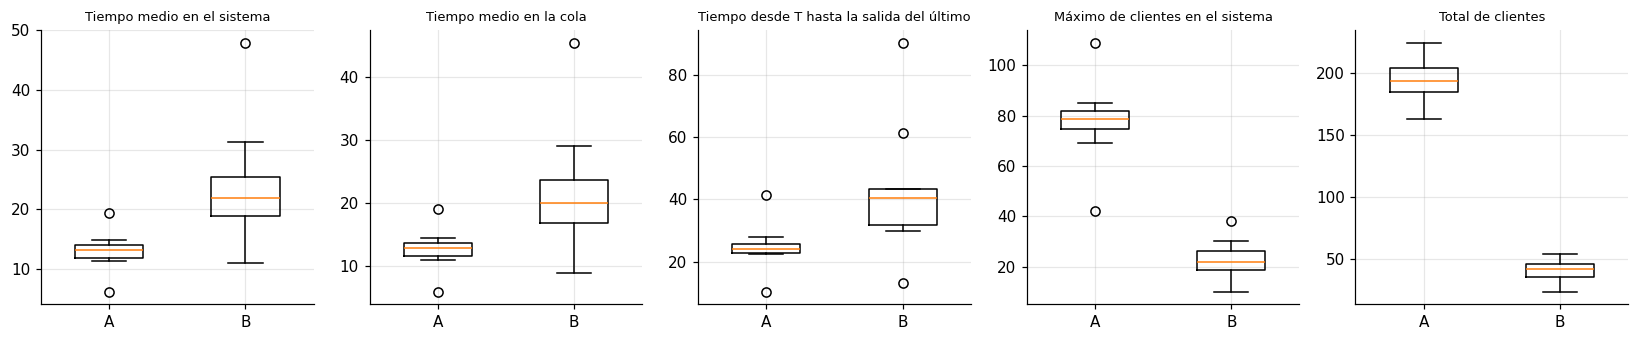

In [10]:
# comparación visual de las 10 corridas
fig, axs = plt.subplots(1, 5, figsize=(15, 3.2))
for ax, col in zip(axs, df_A.columns):
    ax.boxplot([df_A[col], df_B[col]], tick_labels=["A", "B"], widths=0.5)
    ax.set_title(col, fontsize=8.5)
plt.tight_layout(); guardar("51_cajas"); plt.show()


### ¿Qué puede analizar de los resultados comparando los dos escenarios?

**Los dos escenarios son inestables, y eso explica casi todo.** En A llegan 5 clientes por unidad de tiempo
y se atienden 3 ($\rho = 1{,}67$); en B llega 1 y se atiende 0,5 ($\rho = 2$). En ninguno de los dos hay un
estado estable: la cola crece mientras dure la ventana de llegadas. Por eso los resultados dependen de $T$ y
no convergen a un valor fijo.

**Un cálculo sencillo de "flujo" reproduce las cifras de la tabla.** Si la cola crece a razón de
$\lambda - \mu$ clientes por unidad de tiempo, al llegar a $T$ hay unos $(\lambda - \mu)T$ clientes.

- En A: $(5 - 3) \cdot 40 = 80$, y el máximo promedio fue 77,6. Evacuar 80 clientes a 3 por unidad de tiempo
  toma $80/3 \approx 26{,}7$, y el tiempo después de $T$ salió $24{,}8$.
- En B: $(1 - 0{,}5) \cdot 40 = 20$ contra 22,7 observados. Evacuarlos toma $20 \cdot 2 = 40$, contra 42,7.

El mismo razonamiento da el tiempo medio en el sistema. Un cliente que llega en el instante $s$ encuentra
unos $(\lambda - \mu)s$ clientes delante y espera $(\lambda-\mu)s/\mu = (\rho - 1)s$. Promediando sobre
$s \in [0, T]$ queda $(\rho - 1)T/2$: 13,3 en A y 20 en B, frente a 12,97 y 24,00 simulados. La coincidencia
es buena para un modelo que ignora toda la aleatoriedad.

**B es peor para el cliente aunque tenga cinco veces menos tráfico.** En A pasaron 194 clientes en promedio
y en B solo 41, pero en B el cliente promedio pasó 24,0 unidades de tiempo en el sistema, casi el doble que
en A (13,0). Lo que manda no es cuánta gente llega sino la relación entre llegadas y capacidad: en B el
servidor necesita el doble del tiempo disponible y en A "solo" 1,67 veces. También por eso el último cliente
de B sale mucho más tarde (42,7 contra 24,8 después de $T$).

**B es también mucho más variable.** El coeficiente de variación del tiempo en el sistema es 25 % en A
($3{,}31/12{,}97$) y 41 % en B ($9{,}93/24{,}00$). En la corrida 8 de B el último cliente salió 90 unidades
de tiempo después de $T$ y en la corrida 9 solo 13. Con unos 40 clientes por corrida, una racha de llegadas
seguidas o de servicios largos cambia mucho el resultado; en A, con cerca de 200 clientes, esos efectos se
compensan más.

**La cola es casi todo el tiempo en el sistema.** La diferencia entre tiempo en sistema y en cola es 0,33 en
A y 2,01 en B, que son justamente los tiempos medios de servicio (1/3 y 2). Más del 90 % del tiempo de cada
cliente se va esperando. Para mejorar cualquiera de los dos sistemas no basta con optimizar un poco el
servicio: haría falta un segundo servidor o limitar las llegadas, hasta dejar $\rho < 1$.
